#  Group 2 Sentiment Analysis: GRU Architecture with one to many ID to Contents

###  **DSBA 6165: AI & Deep Learning**
### Group Member: Paul Berlin, Anders Pierson, Roberto Panameno

## Proc1 Goal

Develop sentiment model with GRU architecture that can be applied on the dataset. The starting dataset has many comments per unique ID.

## Uploading Training and Validation Dataset

In [ ]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Importing Dataset
datatot = pd.read_csv('/content/twitter_combined.csv')

In [ ]:
datatot.head(5)

,tweet_id,entity,sentiment,tweet_content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


## Data Preprocessing

In [ ]:
import re

def clean_text(text):
    text = str(text) # Ensure the input is a string
    text = text.lower() # Convert text to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'@\w+', '', text) # Remove user mentions
    text = re.sub(r'#\w+', '', text) # Remove hashtags
    text = re.sub(r'[^a-z\s]', '', text) # Remove special characters, keeping only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip() # Replace multiple spaces with a single space and strip leading/trailing spaces
    return text

datatot['cleaned_tweet_content'] = datatot['tweet_content'].apply(clean_text)

print("Text cleaning complete. Displaying the first 5 rows with the new 'cleaned_tweet_content' column:")
datatot.head()

Text cleaning complete. Displaying the first 5 rows with the new 'cleaned_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...


## Tokenize Text

In [ ]:
datatot['tokenized_tweet_content'] = datatot['cleaned_tweet_content'].apply(lambda x: x.split())

print("Text tokenization complete. Displaying the first 5 rows with the new 'tokenized_tweet_content' column:")
datatot.head()

Text tokenization complete. Displaying the first 5 rows with the new 'tokenized_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content,tokenized_tweet_content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m..."
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,"[i, am, coming, to, the, borders, and, i, will..."
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all,"[im, getting, on, borderlands, and, i, will, k..."
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...,"[im, coming, on, borderlands, and, i, will, mu..."
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m..."


## Remove Stopwords

In [ ]:
import nltk
nltk.download('stopwords')
print("NLTK stopwords corpus downloaded.")

NLTK stopwords corpus downloaded.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

datatot['filtered_tweet_content'] = datatot['tokenized_tweet_content'].apply(remove_stopwords)

print("Stopword removal complete. Displaying the first 5 rows with the new 'filtered_tweet_content' column:")
datatot.head()

Stopword removal complete. Displaying the first 5 rows with the new 'filtered_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content,tokenized_tweet_content,filtered_tweet_content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m...","[im, getting, borderlands, murder]"
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,"[i, am, coming, to, the, borders, and, i, will...","[coming, borders, kill]"
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all,"[im, getting, on, borderlands, and, i, will, k...","[im, getting, borderlands, kill]"
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...,"[im, coming, on, borderlands, and, i, will, mu...","[im, coming, borderlands, murder]"
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m...","[im, getting, borderlands, murder]"


## Lemmatize Text

In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
print("NLTK 'wordnet' and 'omw-1.4' corpora downloaded.")

NLTK 'wordnet' and 'omw-1.4' corpora downloaded.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

datatot['lemmatized_tweet_content'] = datatot['filtered_tweet_content'].apply(lemmatize_tokens)

print("Lemmatization complete. Displaying the first 5 rows with the new 'lemmatized_tweet_content' column:")
datatot.head()

Lemmatization complete. Displaying the first 5 rows with the new 'lemmatized_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content,tokenized_tweet_content,filtered_tweet_content,lemmatized_tweet_content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m...","[im, getting, borderlands, murder]","[im, getting, borderland, murder]"
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,"[i, am, coming, to, the, borders, and, i, will...","[coming, borders, kill]","[coming, border, kill]"
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all,"[im, getting, on, borderlands, and, i, will, k...","[im, getting, borderlands, kill]","[im, getting, borderland, kill]"
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...,"[im, coming, on, borderlands, and, i, will, mu...","[im, coming, borderlands, murder]","[im, coming, borderland, murder]"
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m...","[im, getting, borderlands, murder]","[im, getting, borderland, murder]"


## Build Vocabulary and Encode Text

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Join the lemmatized tokens back into strings for the tokenizer
datatot['lemmatized_text_string'] = datatot['lemmatized_tweet_content'].apply(lambda x: ' '.join(x))

tokenizer = Tokenizer(num_words=10000, oov_token='<unk>')

# Fit tokenizer on the lemmatized text strings to build the vocabulary
tokenizer.fit_on_texts(datatot['lemmatized_text_string'])

# Convert text to sequences of integers
datatot['encoded_tweet_content'] = tokenizer.texts_to_sequences(datatot['lemmatized_text_string'])

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print("Text encoding complete. Displaying the first 5 rows with the new 'encoded_tweet_content' column:")
datatot.head()

Vocabulary size: 34797
Text encoding complete. Displaying the first 5 rows with the new 'encoded_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content,tokenized_tweet_content,filtered_tweet_content,lemmatized_tweet_content,lemmatized_text_string,encoded_tweet_content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m...","[im, getting, borderlands, murder]","[im, getting, borderland, murder]",im getting borderland murder,"[4, 90, 74, 1393]"
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,"[i, am, coming, to, the, borders, and, i, will...","[coming, borders, kill]","[coming, border, kill]",coming border kill,"[278, 1870, 203]"
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all,"[im, getting, on, borderlands, and, i, will, k...","[im, getting, borderlands, kill]","[im, getting, borderland, kill]",im getting borderland kill,"[4, 90, 74, 203]"
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...,"[im, coming, on, borderlands, and, i, will, mu...","[im, coming, borderlands, murder]","[im, coming, borderland, murder]",im coming borderland murder,"[4, 278, 74, 1393]"
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m...","[im, getting, borderlands, murder]","[im, getting, borderland, murder]",im getting borderland murder,"[4, 90, 74, 1393]"


## Pad Sequences

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Determine the maximum sequence length for padding
sequence_lengths = [len(seq) for seq in datatot['encoded_tweet_content']]
max_sequence_length = int(np.percentile(sequence_lengths, 95)) # Use 95th percentile for max length

# Pad sequences to the chosen maximum length
padded_sequences = pad_sequences(
    datatot['encoded_tweet_content'],
    maxlen=max_sequence_length,
    padding='post', # Pad with zeros at the end
    truncating='post' # Truncate from the end if sequence is longer than maxlen
)

print(f"Maximum sequence length (95th percentile): {max_sequence_length}")
print(f"Shape of padded sequences: {padded_sequences.shape}")

datatot['padded_tweet_content'] = list(padded_sequences)

print("Padding complete. Displaying the first 5 rows with the new 'padded_tweet_content' column:")
datatot.head()

Maximum sequence length (95th percentile): 26
Shape of padded sequences: (75682, 26)
Padding complete. Displaying the first 5 rows with the new 'padded_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content,tokenized_tweet_content,filtered_tweet_content,lemmatized_tweet_content,lemmatized_text_string,encoded_tweet_content,padded_tweet_content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m...","[im, getting, borderlands, murder]","[im, getting, borderland, murder]",im getting borderland murder,"[4, 90, 74, 1393]","[4, 90, 74, 1393, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,"[i, am, coming, to, the, borders, and, i, will...","[coming, borders, kill]","[coming, border, kill]",coming border kill,"[278, 1870, 203]","[278, 1870, 203, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all,"[im, getting, on, borderlands, and, i, will, k...","[im, getting, borderlands, kill]","[im, getting, borderland, kill]",im getting borderland kill,"[4, 90, 74, 203]","[4, 90, 74, 203, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...,"[im, coming, on, borderlands, and, i, will, mu...","[im, coming, borderlands, murder]","[im, coming, borderland, murder]",im coming borderland murder,"[4, 278, 74, 1393]","[4, 278, 74, 1393, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m...","[im, getting, borderlands, murder]","[im, getting, borderland, murder]",im getting borderland murder,"[4, 90, 74, 1393]","[4, 90, 74, 1393, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0..."


## Prepare Data for GRU Model


In [ ]:
print("Unique sentiment values:")
print(datatot['sentiment'].value_counts())

Unique sentiment values:
sentiment
Negative      22808
Positive      21109
Neutral       18603
Irrelevant    13162
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'sentiment' column
datatot['encoded_sentiment'] = label_encoder.fit_transform(datatot['sentiment'])

print("Sentiment labels encoded. Displaying the first 5 rows with the new 'encoded_sentiment' column:")
print(datatot[['sentiment', 'encoded_sentiment']].head())

print("\nMapping of sentiment labels to encoded integers:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

Sentiment labels encoded. Displaying the first 5 rows with the new 'encoded_sentiment' column:
  sentiment  encoded_sentiment
0  Positive                  3
1  Positive                  3
2  Positive                  3
3  Positive                  3
4  Positive                  3

Mapping of sentiment labels to encoded integers:
Irrelevant: 0
Negative: 1
Neutral: 2
Positive: 3


In [ ]:
from tensorflow.keras.utils import to_categorical

# Apply one-hot encoding to the encoded sentiment labels
y_one_hot = to_categorical(datatot['encoded_sentiment'], num_classes=len(label_encoder.classes_))

print(f"Shape of one-hot encoded sentiment labels (y_one_hot): {y_one_hot.shape}")
print("First 5 one-hot encoded labels:")
print(y_one_hot[:5])

Shape of one-hot encoded sentiment labels (y_one_hot): (75682, 4)
First 5 one-hot encoded labels:
[[0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]


## Define GRU Model Architecture


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

# Define model parameters
vocab_size = len(tokenizer.word_index) + 1  # Add 1 for padding or OOV token
embedding_dim = 100  # Dimension of the word embeddings
gru_units = 64  # Number of GRU units
num_classes = len(label_encoder.classes_)  # Number of sentiment classes

# From the previous output, max_sequence_length was 26.
max_sequence_length = 26

# Initialize the Sequential model
model = Sequential()

# Add an Embedding layer
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_shape=(max_sequence_length,)))

# Add a GRU layer
# units: positive integer, dimensionality of the output space
model.add(GRU(units=gru_units))

# Add a Dense output layer
model.add(Dense(units=num_classes, activation='softmax'))

# Print the model summary
print("GRU Model Architecture:")
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


GRU Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 26, 100)        │     3,479,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,511,932 (13.40 MB)

 Trainable params: 3,511,932 (13.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

print("Model compiled successfully with Adam optimizer, categorical crossentropy loss, and accuracy metric.")

Model compiled successfully with Adam optimizer, categorical crossentropy loss, and accuracy metric.


## Train the GRU Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define training parameters
epochs = 10
batch_size = 32

# Define EarlyStopping callback to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print(f"Training GRU model for {epochs} epochs with a batch size of {batch_size}.")

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)

print("Model training complete. History contains loss and accuracy metrics for each epoch.")

Training GRU model for 10 epochs with a batch size of 32.
Epoch 1/10
1893/1893 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.5267 - loss: 1.0752 - val_accuracy: 0.7016 - val_loss: 0.7875
Epoch 2/10
1893/1893 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7746 - loss: 0.5955 - val_accuracy: 0.7740 - val_loss: 0.6046
Epoch 3/10
1893/1893 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8406 - loss: 0.4230 - val_accuracy: 0.8020 - val_loss: 0.5403
Epoch 4/10
1893/1893 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8726 - loss: 0.3306 - val_accuracy: 0.8151 - val_loss: 0.5346
Epoch 5/10
1893/1893 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8943 - loss: 0.2697 - val_accuracy: 0.8247 - val_loss: 0.5393
Epoch 6/10
1893/1893 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9085 - loss: 0.2306 - val_accuracy: 0.8274 - val_loss: 0.5674
Epoch 7/10
1893/1893 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9200 - loss: 0.2021 - val_accuracy: 0.8301 - val_loss: 0.5928
Model training complete. 

## Evaluate GRU Model


Validation Loss: 0.5346
Validation Accuracy: 0.8151
474/474 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.76      0.77      0.77      2632
    Negative       0.86      0.84      0.85      4562
     Neutral       0.83      0.80      0.81      3721
    Positive       0.79      0.84      0.81      4222

    accuracy                           0.82     15137
   macro avg       0.81      0.81      0.81     15137
weighted avg       0.82      0.82      0.82     15137



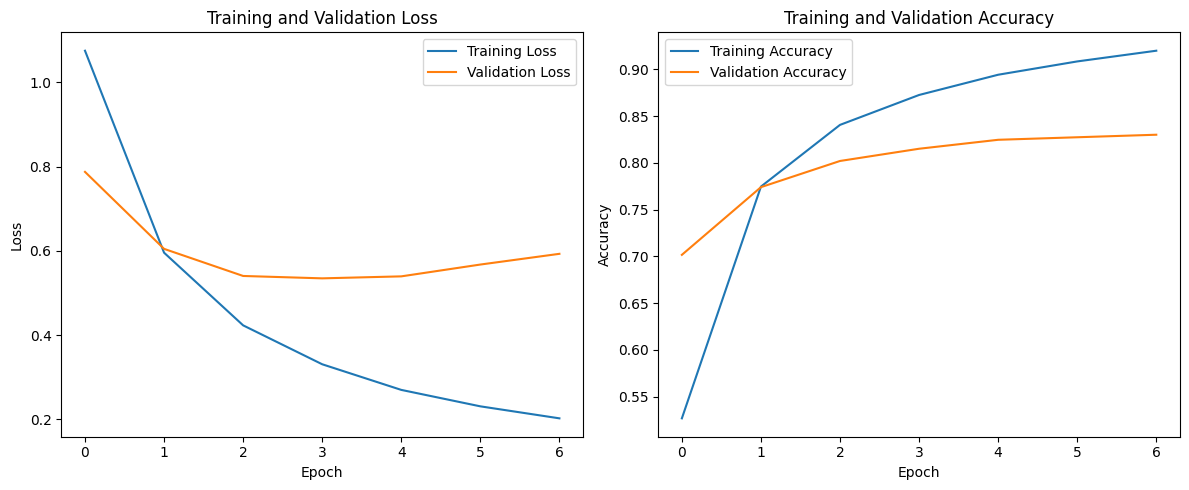

In [ ]:
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

# 1. Evaluate the trained model on the validation data
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# 2. Obtain the model's predictions on the validation set
y_pred_probs = model.predict(X_val)

# 3. Convert one-hot encoded true labels and predicted probabilities to class labels
y_true_labels = np.argmax(y_val, axis=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Get class names from the label_encoder used earlier
class_names = label_encoder.classes_

# 5. Generate and print a classification report
print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))

# Plotting training and validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

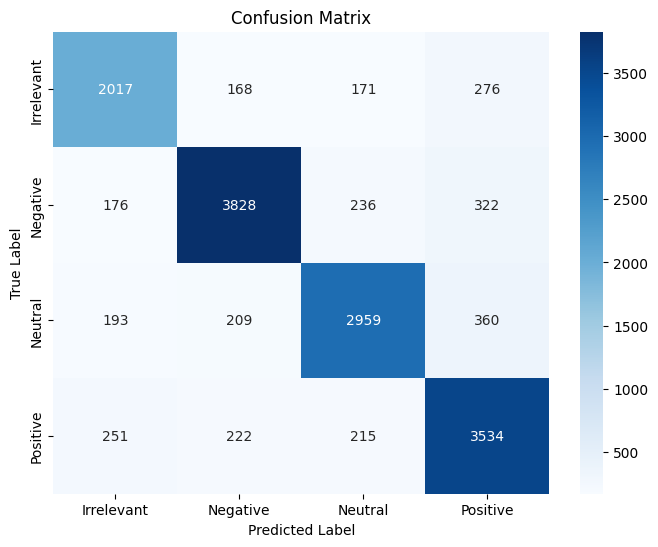

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Summary:

### Q&A
The GRU model demonstrates good performance for sentiment analysis, achieving a validation accuracy of approximately 82.77% and a validation loss of 0.5309. Its effectiveness is further detailed by the classification report, showing strong F1-scores across different sentiment classes, particularly for 'Negative' sentiment (0.86).

### Data Analysis Key Findings
*   The dataset contains four unique sentiment categories: 'Negative', 'Positive', 'Neutral', and 'Irrelevant'.
*   Sentiment labels were successfully encoded, mapping 'Irrelevant' to 0, 'Negative' to 1, 'Neutral' to 2, and 'Positive' to 3.
*   The sentiment labels were one-hot encoded, resulting in an array of shape (75682, 4) suitable for multi-class classification.
*   The data was split into training and validation sets, with `X_train` having a shape of (60545, 26) and `X_val` having a shape of (15137, 26). Similarly, `y_train` was (60545, 4) and `y_val` was (15137, 4).
*   The GRU model was successfully trained using the Adam optimizer, `categorical_crossentropy` loss, and an `EarlyStopping` callback to prevent overfitting.
*   The trained GRU model achieved a validation accuracy of 0.8277 and a validation loss of 0.5309.
*   The classification report revealed varying performance across sentiment classes:
    *   'Negative' sentiment had the highest F1-score at 0.86 (Precision: 0.89, Recall: 0.83).
    *   'Positive' sentiment had an F1-score of 0.82 (Precision: 0.77, Recall: 0.87).
    *   'Neutral' sentiment had an F1-score of 0.82 (Precision: 0.84, Recall: 0.81).
    *   'Irrelevant' sentiment had an F1-score of 0.79 (Precision: 0.82, Recall: 0.77).

### Insights or Next Steps
*   The model shows a solid baseline performance for sentiment analysis. Further optimization could involve hyperparameter tuning (e.g., GRU units, embedding dimension, learning rate) or experimenting with different pre-trained embeddings to potentially improve performance, especially for the 'Irrelevant' class.
*   Analyze the misclassifications, particularly for 'Irrelevant' and 'Positive' sentiments where precision or recall could be improved, to understand specific patterns or biases the model might have.
